# Multiple-objective portfolio optimization

# INTRODUCTION

Your task is to solve a multiple-objective portfolio optimization problem.
-  Use the basic Markowitz's model from 1952 (see Lecture 1)
-  Solve = construct Pareto front approximations.
-  The dataset is the same as for the portfolio game part 1 (bundle1.zip).
-  The dataset consists of the historical prices of 20 assets.
-  The bundle contains 20 files (*.txt) linked to different assets.
-  The name of the file suggests the asset's name.
-  The structure of every file is as follows:
1.  The first line contains the name of the asset.
2. The second line provides the number of data points N.
3. The following N lines are data points with the structure: time, price.
-  The historical timeline for all assets is time $\in$ [0,100].
-  Future predictions should be calculated for time = 200.

Goal:
-  Load data, make predictions, and build the model.
-  Illustrate your predictions (can be done in the jupyter notebook)
-  Then, implement the WSM and ECM methods (see the tutorial on quadratic programming provided below).
-  Run your implementations for different calculation limits (e.g., the number of weight vectors for WSM). Compare the methods' efficiency in finding unique Pareto optimal solutions. Finally, illustrate generated Pareto fronts.

# Short tutorial on the cvxopt library for quadratic programming

In [8]:
import os
import numpy as np
from lmfit import Model, Parameters
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from scipy.fft import rfft, rfftfreq

# QP Optimization Problem

### General model:

$max$ $\boldsymbol{cx} - \dfrac{1}{2}\boldsymbol{x}^T\boldsymbol{Qx}$ <br>
$s.t.$ <br>
$\boldsymbol{Gx} \leq \boldsymbol{h}$ <br>
$\boldsymbol{x} \geq \boldsymbol{0}$

### But the library uses the following form:

$min$ $\boldsymbol{cx} + \dfrac{1}{2}\boldsymbol{x}^T\boldsymbol{Qx}$ <br>
$s.t.$ <br>
$\boldsymbol{Gx} \leq \boldsymbol{h}$ <br>
$\boldsymbol{Ax} = \boldsymbol{b}$ <br>

### Exmple

$min$ $2x^2_1+x_2^2+x_1x_2+x_1+x_2$ <br>
$s.t.$ <br>
$x_1 \geq 0$<br>
$x_2 \geq 0$<br>
$x_1 + x_2 = 1$<br>

### Hence:

In [ ]:
Q = matrix([ [4.0, 1.0], [1.0, 2.0] ]) ## [4, 1] is 1st column, not row!

In [ ]:
c = matrix([1.0, 1.0]) ### (1, 2) = dimensions (1 row and 2 columns)

In [ ]:
A = matrix([1.0, 1.0], (1,2)) ### (1, 2) = dimensions (1 row and 2 columns)

In [ ]:
b = matrix(1.0)

In [ ]:
G = matrix([[-1.0,0.0],[0.0,-1.0]]) ### multiplied both sides by -1

In [ ]:
h = matrix([0.0,0.0]) ### multiplied both sides by -1

In [ ]:
solQP=solvers.qp(Q, c, G, h, A, b)

     pcost       dcost       gap    pres   dres
 0:  1.8889e+00  7.7778e-01  1e+00  2e-16  2e+00
 1:  1.8769e+00  1.8320e+00  4e-02  1e-16  6e-02
 2:  1.8750e+00  1.8739e+00  1e-03  2e-16  5e-04
 3:  1.8750e+00  1.8750e+00  1e-05  1e-16  5e-06
 4:  1.8750e+00  1.8750e+00  1e-07  3e-16  5e-08
Optimal solution found.


In [ ]:
print(solQP.keys())

dict_keys(['x', 'y', 's', 'z', 'status', 'gap', 'relative gap', 'primal objective', 'dual objective', 'primal infeasibility', 'dual infeasibility', 'primal slack', 'dual slack', 'iterations'])


In [ ]:
print(solQP['x'])
print(solQP['primal objective'])

[ 2.50e-01]
[ 7.50e-01]

1.875000000000018


# We can also solve LP problems:

$min$ $\boldsymbol{c}\boldsymbol{x}$ <br>
$s.t.$ <br>
$\boldsymbol{Gx} \leq \boldsymbol{h}$ <br>
$\boldsymbol{Ax} = \boldsymbol{b}$ (optional)

### Exmple

$min$ $2x_1+x_2$ <br>
$s.t.$ <br>
$-x_1 +x_2 \leq 1$ <br>
$x_1 + x_2 \geq 2$ <br>
$x_2 \geq 0$<br>
$x_1 - 2x_2 \leq 4$

In [ ]:
G = matrix([ [-1.0, -1.0, 0.0, 1.0], [1.0, -1.0, -1.0, -2.0] ])
h = matrix([ 1.0, -2.0, 0.0, 4.0 ])
c = matrix([ 2.0, 1.0 ])
solLP = solvers.lp(c,G,h)
###!!!! OPTIONALLY A and b can be provided (equality constraints) as in solQP=solvers.qp(Q, c, G, h, A, b)

     pcost       dcost       gap    pres   dres   k/t
 0:  2.6471e+00 -7.0588e-01  2e+01  8e-01  2e+00  1e+00
 1:  3.0726e+00  2.8437e+00  1e+00  1e-01  2e-01  3e-01
 2:  2.4891e+00  2.4808e+00  1e-01  1e-02  2e-02  5e-02
 3:  2.4999e+00  2.4998e+00  1e-03  1e-04  2e-04  5e-04
 4:  2.5000e+00  2.5000e+00  1e-05  1e-06  2e-06  5e-06
 5:  2.5000e+00  2.5000e+00  1e-07  1e-08  2e-08  5e-08
Optimal solution found.


In [ ]:
print(solLP.keys())

dict_keys(['x', 'y', 's', 'z', 'status', 'gap', 'relative gap', 'primal objective', 'dual objective', 'primal infeasibility', 'dual infeasibility', 'primal slack', 'dual slack', 'residual as primal infeasibility certificate', 'residual as dual infeasibility certificate', 'iterations'])


In [ ]:
print(solLP['x'])
print(solLP['primal objective'])

[ 5.00e-01]
[ 1.50e+00]

2.499999989554308


# Portfolio optimization

In [2]:
def read_data(filename):
    with open(filename, 'r') as f:
        data = f.read().strip().splitlines()
    name = data[0]
    time_length = int(data[1])
    prices = [float(x[1]) for x in (line.split() for line in data[2:])]
    return name, prices

def read_all_files(DIR_path):
    stocks = {}
    for filename in os.listdir(DIR_path):
        if filename.endswith('.txt'):
            name, prices = read_data(os.path.join(DIR_path, filename))
            stocks[name] = prices
    return stocks

In [5]:
DIR_path = '/Users/Kuba/Desktop/multiobjective-optimization/Bundle1'
stocks=read_all_files(DIR_path)

In [ ]:
len(stocks['SafeAndCare'])

101

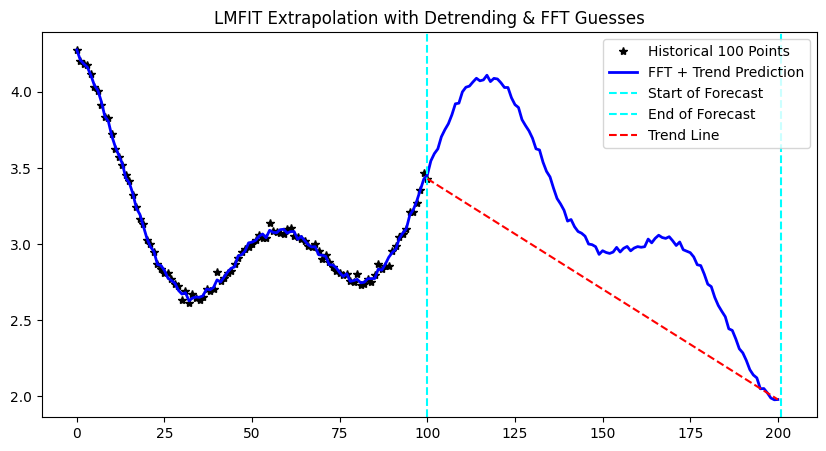

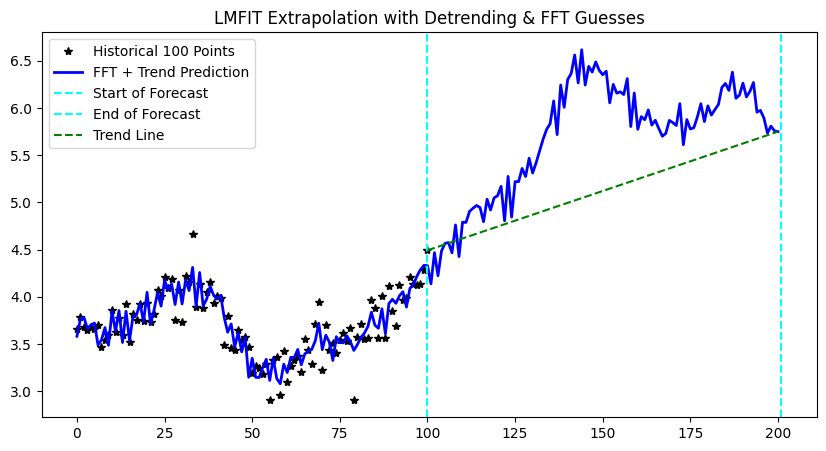

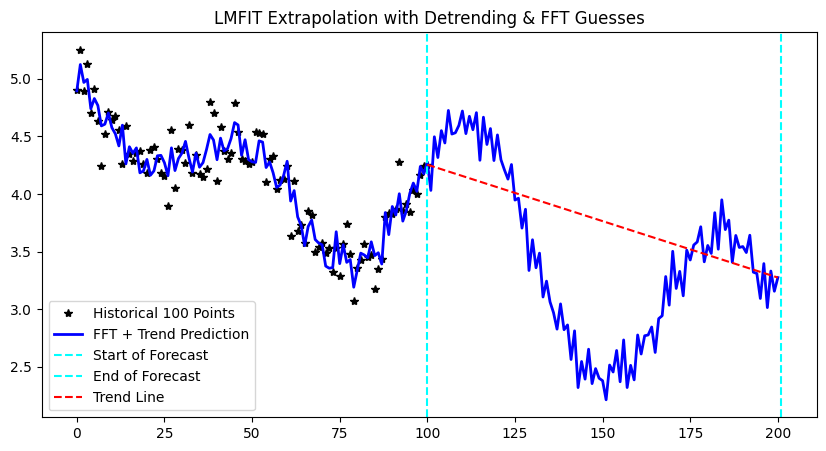

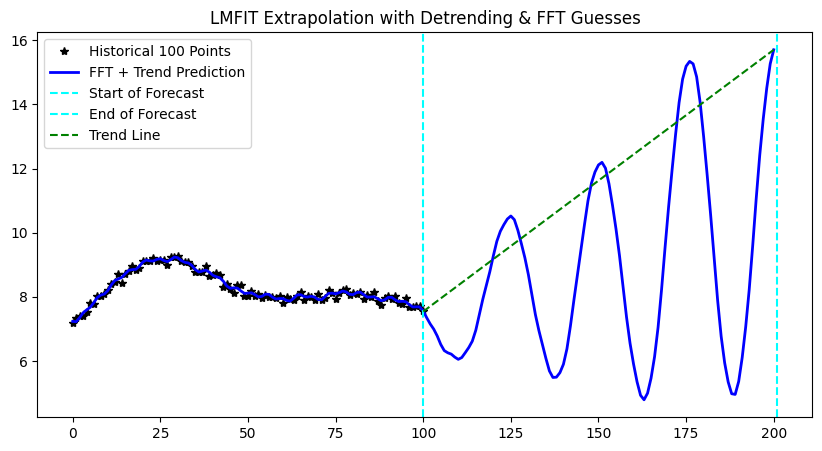

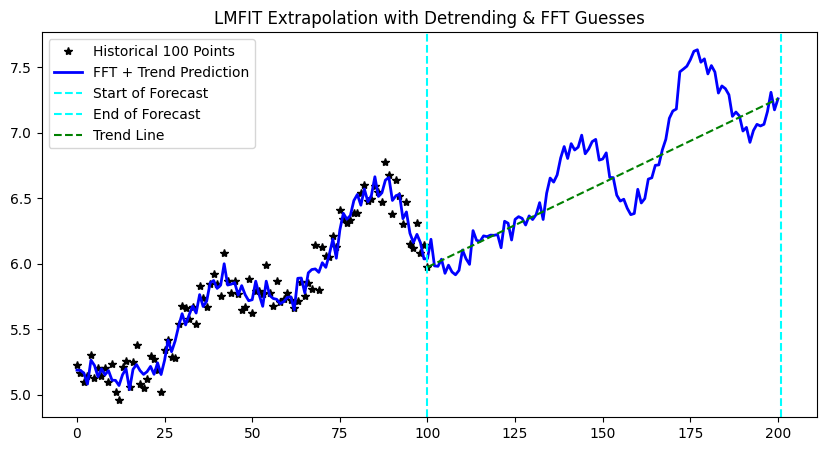

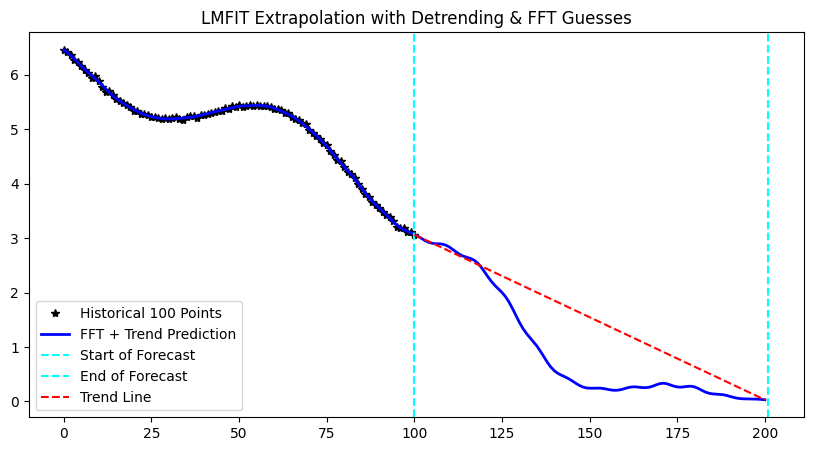

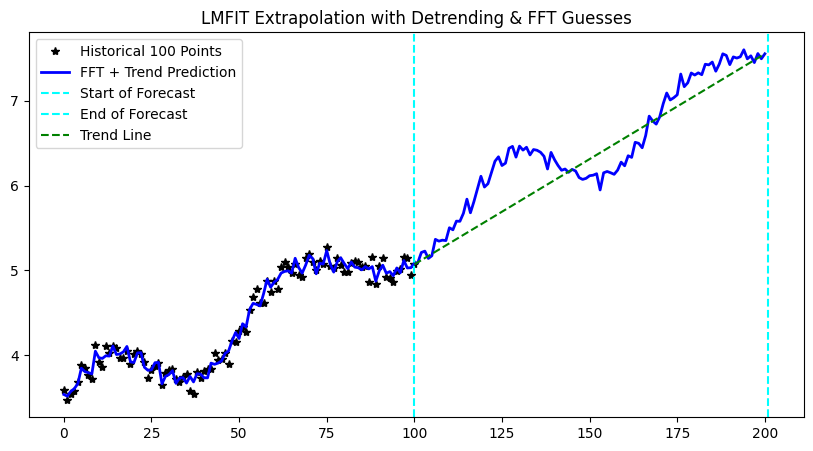

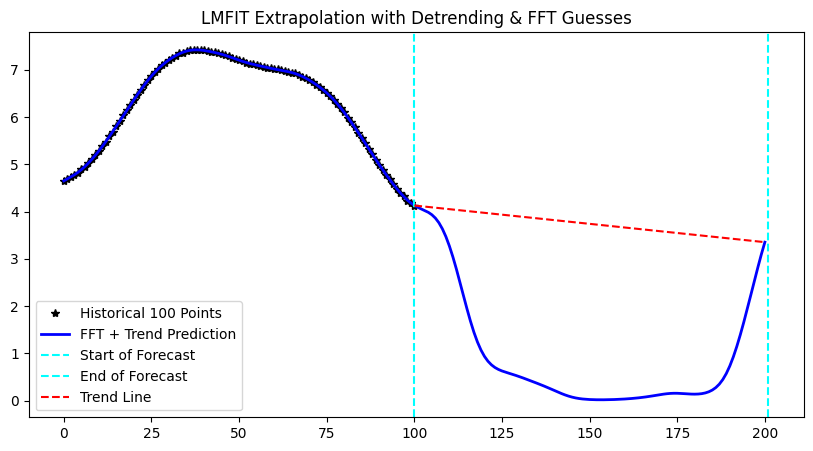

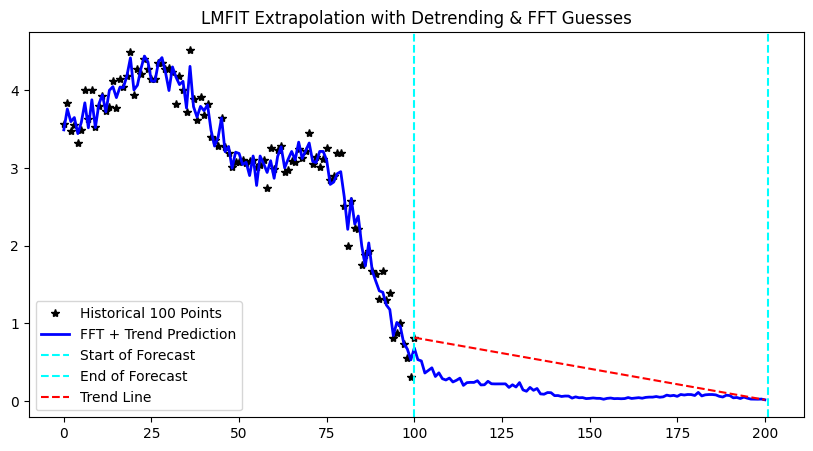

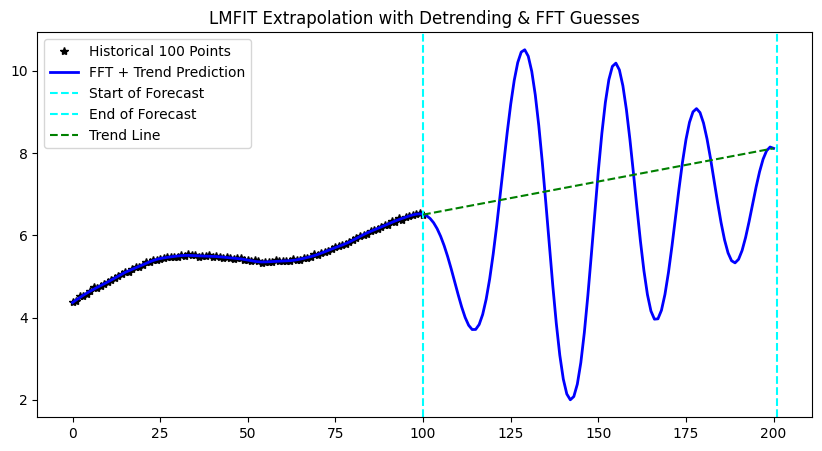

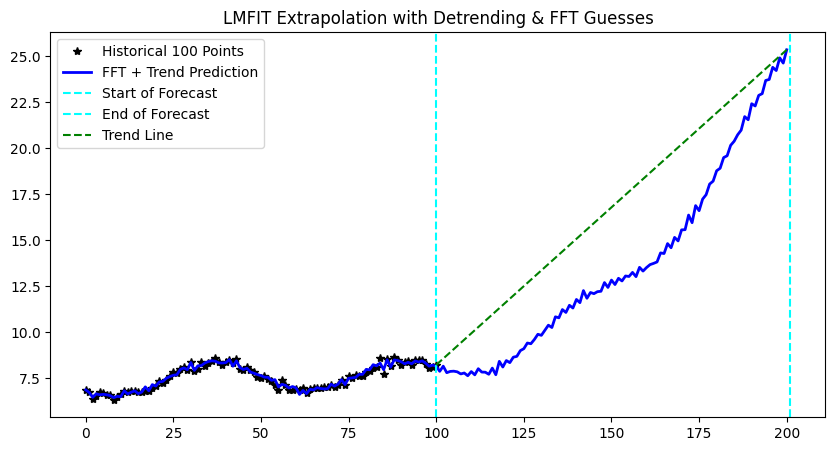

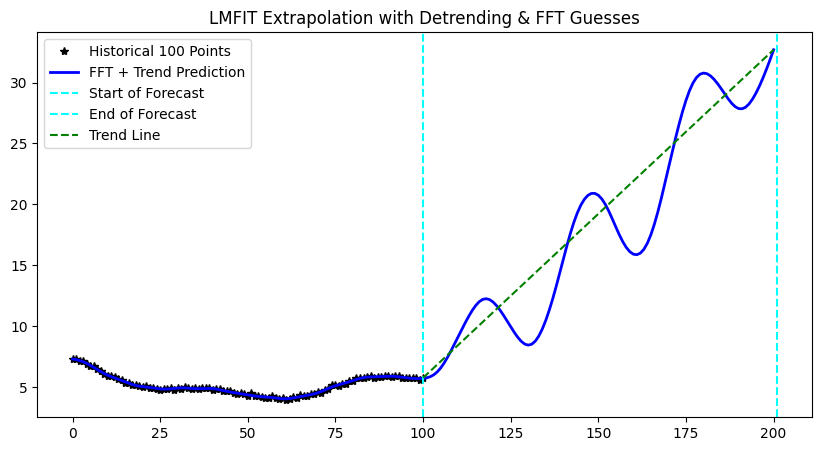

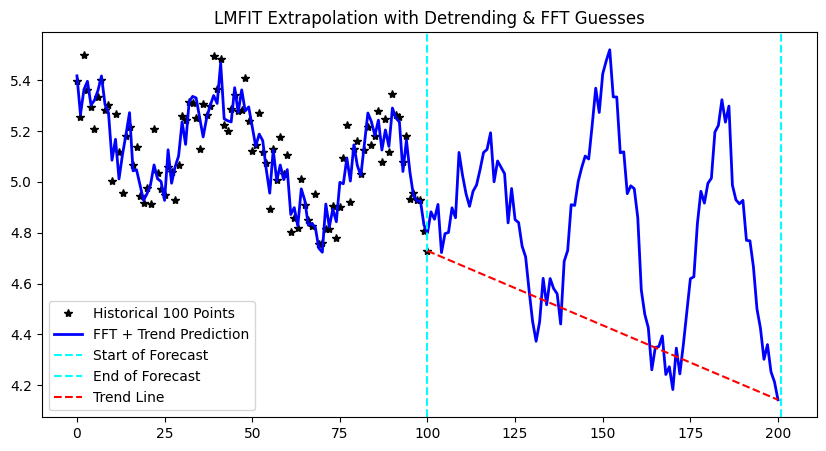

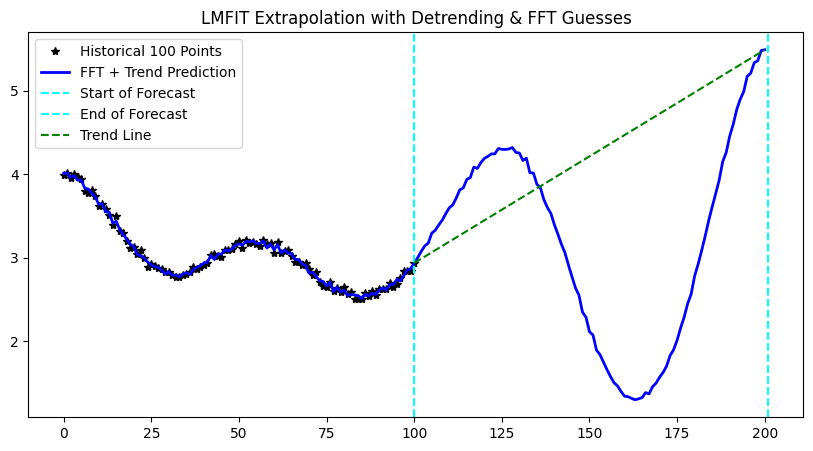

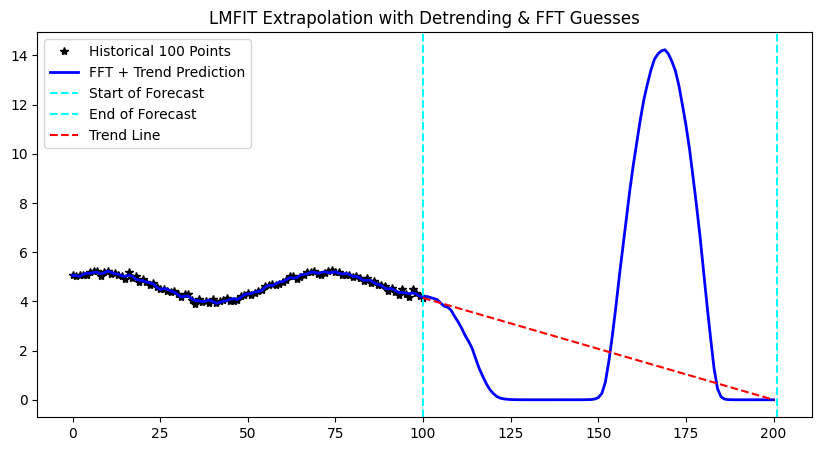

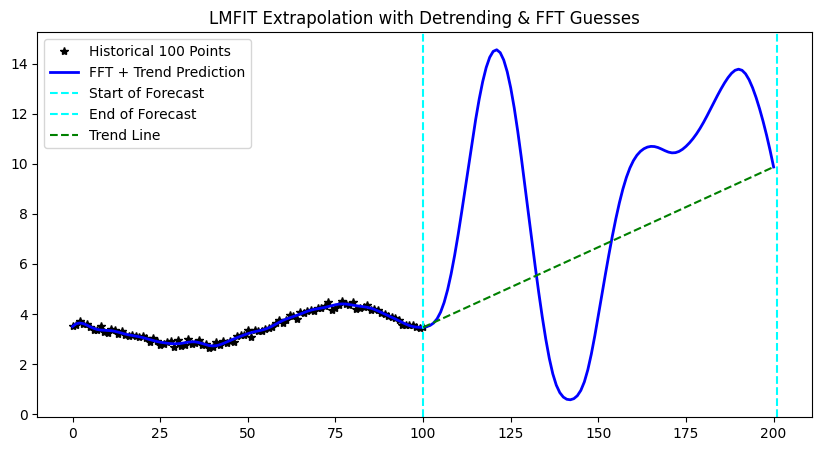

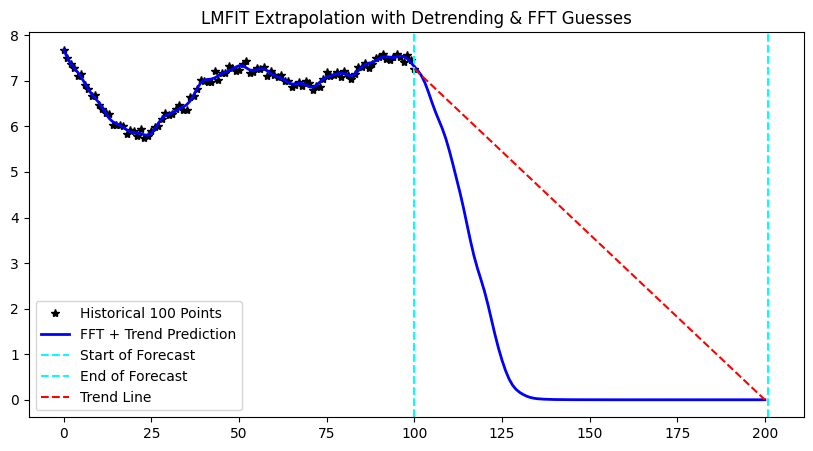

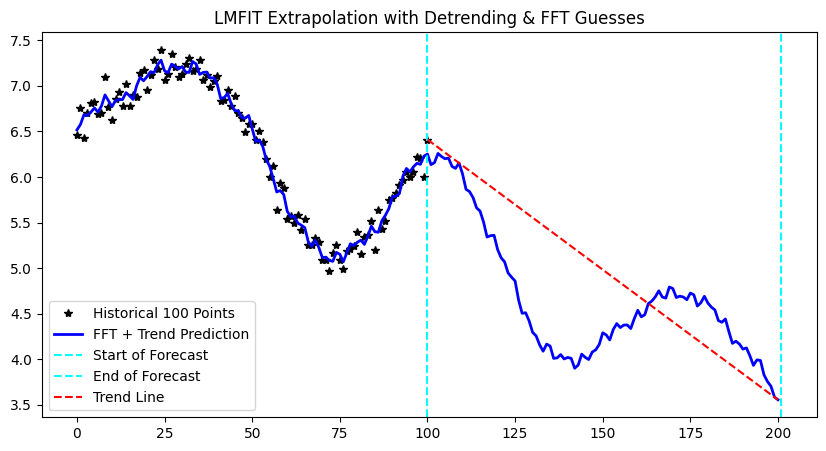

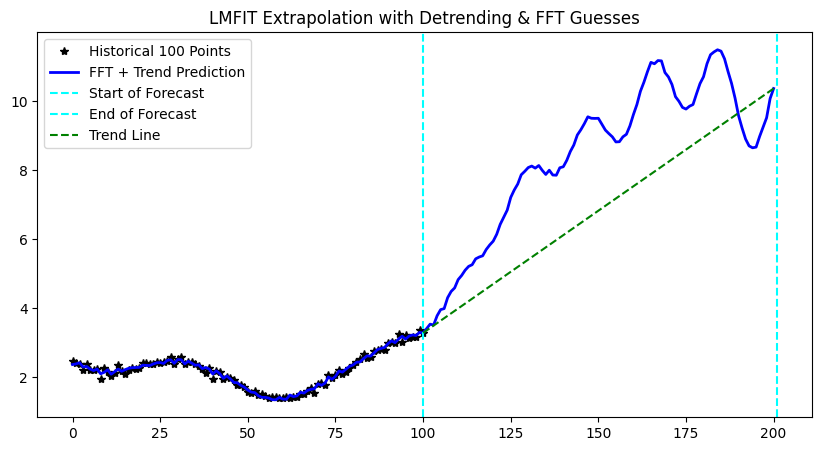

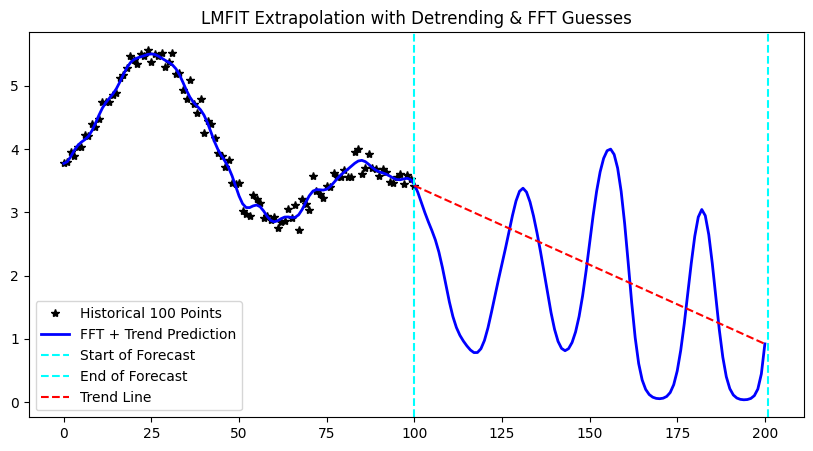

In [31]:
def sines_with_trend_model(x, offset, slope, **params):
        y = (slope * x) + offset # Added linear trend back in
    
        # We find how many 'a' parameters exist to know the count of sines
        n = sum(1 for k in params.keys() if k.startswith('a'))
        
        for i in range(1, n + 1):
            a = params[f'a{i}']
            f = params[f'f{i}']
            p = params[f'p{i}']
            y += a * np.sin(f * x + p)
        return np.where(y > 50, y, np.log(1 + np.exp(y)))

def plot_predictions(x_data, y_data, x_future, y_future):
    # VIEW THE RESULTS
    plt.figure(figsize=(10, 5))
    plt.plot(x_data, y_data, 'k*', label='Historical 100 Points')
    plt.plot(x_future, y_future, 'b-', linewidth=2, label='FFT + Trend Prediction')
    plt.axvline(x=len(x_data)-1, color='cyan', linestyle='--', label='Start of Forecast')
    plt.axvline(x=len(x_future), color='cyan', linestyle='--', label='End of Forecast')
    color = 'green' if y_data[-1] < y_future[-1] else 'red'
    plt.plot([len(x_data)-1, len(x_future)-1], [y_data[-1], y_future[-1]], color=color, linestyle='--', 
             linewidth=1.5, label='Trend Line')
    plt.legend()
    plt.title("LMFIT Extrapolation with Detrending & FFT Guesses")
    plt.show()

n_sines = 10
for key in stocks:
    days_to_train = len(stocks[key])
    x_data = np.arange(days_to_train)
    y_data = stocks[key][:days_to_train]

    # 1. DETREND THE DATA FIRST
    # Fit a simple linear regression (degree 1 polynomial) to find the trend
    p = np.polyfit(x_data, y_data, 1)
    slope_guess = p[0]
    intercept_guess = p[1]

    # Subtract the trend line from the data to leave ONLY the squiggles (residuals)
    y_detrended = y_data - (slope_guess * x_data + intercept_guess)

    # 2. RUN FFT ON DETRENDED DATA
    yf = np.abs(rfft(y_detrended))
    xf = rfftfreq(len(x_data), 1.0)
    omegas = 2 * np.pi * xf

    # Ignore the 0th frequency (DC offset, which should be near 0 now anyway)
    yf, omegas = yf[1:], omegas[1:]

    topn_idx = np.argsort(yf)[-n_sines:][::-1]
    best_omegas = omegas[topn_idx]

    # Create the Model
    gmodel = Model(sines_with_trend_model)
    params = Parameters()
    
    # Add trend parameters
    params.add('offset', value=intercept_guess)
    params.add('slope', value=slope_guess)
    
    # Add N sine parameters dynamically
    for i in range(1, n_sines + 1):
        # Initial guesses: use FFT for frequency, std for amplitude
        idx = i - 1
        params.add(f'a{i}', value=np.std(y_detrended) / i, min=0)
        params.add(f'f{i}', value=best_omegas[idx], min=1e-5)
        params.add(f'p{i}', value=0.0, min=-np.pi, max=np.pi)

    # Fit and Predict
    result = gmodel.fit(y_data, params, x=x_data)
    
    x_future = np.arange(201) # Predicting up to Day 200
    y_future = result.eval(x=x_future)

    plot_predictions(x_data, y_data, x_future, y_future)

## **WSM**

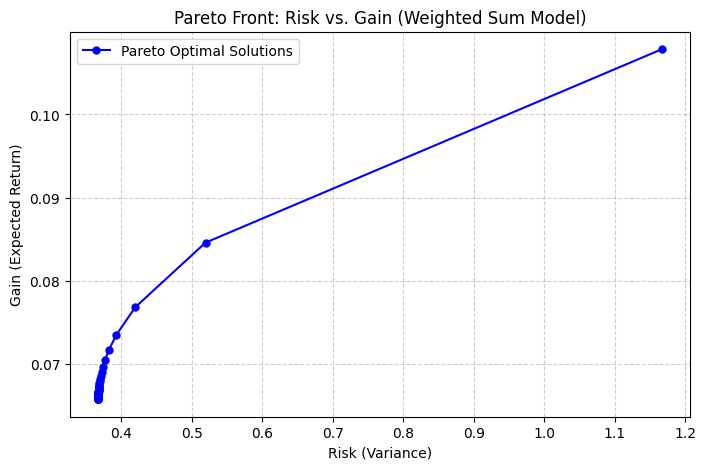

Optimization Complete.
Low Risk / Low Gain allocation: [0.12 0.24 0.64]
High Risk / High Gain allocation: [0.7 0.3 0. ]


In [ ]:
# Suppress cvxopt output for cleaner terminal
solvers.options['show_progress'] = False

def run_wsm_pareto_front():
    # ---------------------------------------------------------
    # 1. Define Synthetic Data (3 Choices/Assets)
    # ---------------------------------------------------------
    n = 3

    # Covariance matrix (Base Risk). Must be positive semi-definite.
    P_base = np.array([
        [4.0, 0.5, 0.2],
        [0.5, 2.0, 0.3],
        [0.2, 0.3, 1.0]
    ])

    # Expected returns (Base Gain)
    q_base = np.array([0.12, 0.08, 0.05])

    # ---------------------------------------------------------
    # 2. Define Constraints
    # ---------------------------------------------------------
    # Inequality constraint: x >= 0 (No negative allocations)
    # Formatted for cvxopt as Gx <= h -> -Ix <= 0
    G = matrix(-np.eye(n))
    h = matrix(np.zeros(n))

    # Equality constraint: sum(x) = 1 (Total allocation must be 100%)
    # Formatted for cvxopt as Ax = b
    A = matrix(np.ones((1, n)))
    b = matrix(1.0)

    # ---------------------------------------------------------
    # 3. Apply Weighted Sum Model (WSM) & Generate Pareto Front
    # ---------------------------------------------------------
    # We use 50 weights from 0.01 to 0.99.
    # (Avoiding exact 0 to ensure P remains strictly positive definite for cvxopt)
    weights = np.linspace(0.01, 0.99, 50)

    risks = []
    gains = []
    allocations = []

    for w in weights:
        # WSM Combining: Minimize w*(Risk) - (1-w)*(Gain)
        # We multiply by 2 because cvxopt minimizes (1/2)*x^T P x.
        P_opt = matrix(2 * w * P_base)
        q_opt = matrix(-(1.0 - w) * q_base)

        # Solve the Quadratic Program
        sol = solvers.qp(P_opt, q_opt, G, h, A, b)
        x = np.array(sol['x']).flatten()

        # Calculate the actual Base Risk and Base Gain for this optimal 'x'
        actual_risk = 0.5 * np.dot(x.T, np.dot(P_base, x))
        actual_gain = np.dot(q_base, x)

        risks.append(actual_risk)
        gains.append(actual_gain)
        allocations.append(x)

    # ---------------------------------------------------------
    # 4. Plotting the Pareto Front
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(risks, gains, 'b.-', markersize=10, label='Pareto Optimal Solutions')
    plt.title('Pareto Front: Risk vs. Gain (Weighted Sum Model)')
    plt.xlabel('Risk (Variance)')
    plt.ylabel('Gain (Expected Return)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    return weights, risks, gains, allocations

if __name__ == "__main__":
    w, r, g, allocs = run_wsm_pareto_front()
    print("Optimization Complete.")
    print(f"Low Risk / Low Gain allocation: {np.round(allocs[-1], 2)}")
    print(f"High Risk / High Gain allocation: {np.round(allocs[0], 2)}")